<div dir="rtl">

# آزمون فرض

در این نوت‌بوک دو فرضیه‌ی صورت پروژه را بررسی می‌کنیم:
1. آیا داشتن سند تجاری بر قیمت فروش ملک تجاری اثر معنادار دارد؟
2. امکانات لوکس قیمت را بالا می‌برند، ولی آیا امکانات غیرلوکس هم اثر معنادار دارند؟

داده از خروجی پیش‌پردازش ستون‌های بولین و مکان (`pre_processing_shahab.parquet`) و ستون قیمت فایل اصلی خوانده می‌شود.

</div>

<div dir="rtl">

## ۱. خواندن داده

خروجی پیش‌پردازش را با ستون‌های دسته، شهر و قیمت فروش از فایل اصلی ترکیب می‌کنیم. اتصال با `row_id` انجام می‌شود.

</div>

In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
shahab = pd.read_parquet("../data/pre_processing_shahab.parquet")

raw = pd.read_csv("../data/Divar.csv",
                  usecols=["Unnamed: 0", "cat2_slug", "cat3_slug", "city_slug", "price_value"])
raw = raw.rename(columns={"Unnamed: 0": "row_id"})

df = raw.merge(shahab, on="row_id", how="left")

print(df.shape)
df[["row_id", "cat3_slug", "city_slug", "price_value", "has_business_deed"]].head()

(1000000, 34)


,row_id,cat3_slug,city_slug,price_value,has_business_deed
0,0,villa,karaj,NaN,<NA>
1,1,apartment-sell,tehran,8.500000e+09,<NA>
2,2,apartment-rent,tehran,NaN,<NA>
3,3,office-rent,tehran,NaN,<NA>
4,4,apartment-sell,mashhad,5.750000e+09,<NA>


<div dir="rtl">

## ۲. تمیزکاری موقت قیمت

این تمیزکاری فقط برای همین نوت‌بوک است تا وقتی خروجی بخش مالی آماده شود.

فقط آگهی‌های فروش را نگه داشتیم. قیمت‌هایی که همه رقم‌هایشان یکی است مثل ۹۹۹۹۹۹۹ حذف شدند. قیمت‌های زیر ۱۰۰ میلیون تومان هم حذف شدند چون بیشترشان به میلیون نوشته شده‌اند. در آخر ۱ درصد پایین و بالای قیمت هر دسته را جدا حذف کردیم چون قیمت ویلا و مغازه با هم قابل مقایسه نیست.

در نهایت ۵۳۱ هزار آگهی سالم ماند.

</div>

In [15]:
is_sale = df["cat2_slug"].str.endswith("-sell")
sale = df[is_sale & (df["price_value"] > 0)].copy()

def is_fake_price(price):
    digits = str(int(price))
    return len(digits) >= 6 and len(set(digits)) == 1

sale = sale[~sale["price_value"].apply(is_fake_price)]
sale = sale[sale["price_value"] >= 1e8]

limits = sale.groupby("cat3_slug")["price_value"].quantile([0.01, 0.99]).unstack()
limits.columns = ["low", "high"]
sale = sale.merge(limits, on="cat3_slug")

sale = sale[sale["price_value"].between(sale["low"], sale["high"])]
print(f"آگهی‌های فروش سالم: {len(sale):,}")

summary = sale.groupby("cat3_slug")["price_value"].agg(["count", "median"])
summary["median"] = (summary["median"] / 1e9).round(2)
summary.sort_values("count", ascending=False)

آگهی‌های فروش سالم: 531,612


,count,median
cat3_slug,,
apartment-sell,289218,3.40
house-villa-sell,110444,2.90
plot-old,103356,1.40
shop-sell,16667,3.51
industry-agriculture-business-sell,7782,3.04
office-sell,4145,7.20


<div dir="rtl">

# فرضیه اول: اثر سند تجاری

فرض صفر این است که قیمت ملک تجاری با سند و بدون سند فرقی ندارد. فرض مقابل اینه که فرق داره


سند تجاری فقط در سه دسته پره: مغازه و دفتر و ملک صنعتی. هر دسته را جدا بررسی کردم تا نوع ملک با اثر سند قاطی نشد.

## ۳. نگاه اول به دو گروه

قیمت‌ها خیلی پخش‌اند برای همین نمودار در مقیاس لگاریتمی کشیده شده.

</div>

count  median
cat3_slug                          has_business_deed               
industry-agriculture-business-sell False               3415    2.40
                                   True                3794    4.20
office-sell                        False               1377    6.50
                                   True                1944    6.75
shop-sell                          False               7726    3.30
                                   True                7014    3.70

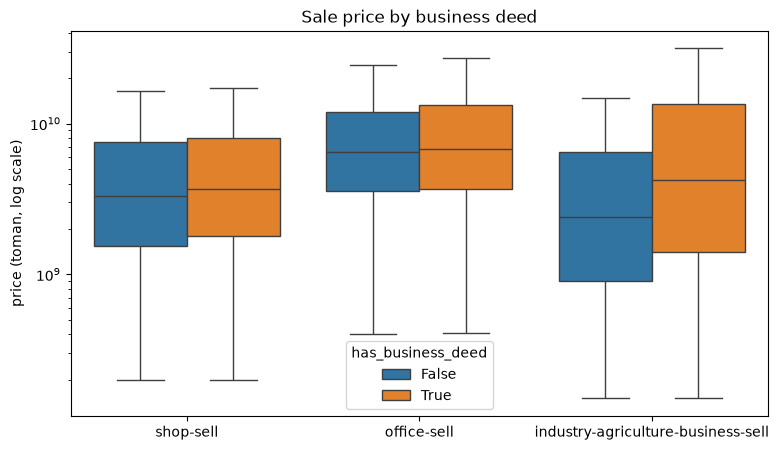

In [16]:
commercial_cats = ["shop-sell", "office-sell", "industry-agriculture-business-sell"]
commercial = sale[sale["cat3_slug"].isin(commercial_cats)]
commercial = commercial[commercial["has_business_deed"].notna()]

table = commercial.groupby(["cat3_slug", "has_business_deed"])["price_value"].agg(["count", "median"])
table["median"] = (table["median"] / 1e9).round(2)
display(table)

plt.figure(figsize=(9, 5))
sns.boxplot(data=commercial, x="cat3_slug", y="price_value", hue="has_business_deed", showfliers=False)
plt.yscale("log")
plt.ylabel("price (toman, log scale)")
plt.xlabel("")
plt.title("Sale price by business deed")
plt.show()

<div dir="rtl">

## ۴. آزمون در کل ایران

دو آزمون زدیم. t-test روی لگاریتم قیمت چون خود قیمت نرمال نیست. Mann-Whitney هم چون هیچ فرضی درباره توزیع نداره  و برای قیمت مطمئن است.

کنار p-valuاختلاف میانه قیمت را هم اوردم . p-value فقط می‌گه اختلاف شانسی نیست ولی نمی‌گوید چقدر بزرگ است.

</div>

In [17]:
results = []
for cat in commercial_cats:
    group = commercial[commercial["cat3_slug"] == cat]
    with_deed = group[group["has_business_deed"] == True]["price_value"]
    without_deed = group[group["has_business_deed"] == False]["price_value"]
    t_p = stats.ttest_ind(np.log(with_deed), np.log(without_deed), equal_var=False).pvalue
    u_p = stats.mannwhitneyu(with_deed, without_deed).pvalue
    diff = (with_deed.median() / without_deed.median() - 1) * 100

    results.append({
        "category": cat,
        "with_deed": len(with_deed),
        "without_deed": len(without_deed),
        "median_diff_%": round(diff, 1),
        "t_test_p": t_p,
        "mann_whitney_p": u_p,
        "significant": u_p < 0.05,
    })

deed_results = pd.DataFrame(results)
deed_results

,category,with_deed,without_deed,median_diff_%,t_test_p,mann_whitney_p,significant
0,shop-sell,7014,7726,12.1,6.201947e-08,9.213280e-08,True
1,office-sell,1944,1377,3.8,2.579606e-02,3.879751e-02,True
2,industry-agriculture-business-sell,3794,3415,75.0,1.046814e-47,1.838595e-47,True


<div dir="rtl">

## ۵. آزمون فقط در تهران

شاید ملک‌های سنددار بیشتر در شهرهای گران باشند و گرانی‌شان به خاطر شهر باشد نه سند. برای همین آزمون را فقط در تهران تکرار کردم

</div>

In [18]:
def deed_test(data):
    results = []
    for cat in commercial_cats:
        group = data[data["cat3_slug"] == cat]
        with_deed = group[group["has_business_deed"] == True]["price_value"]
        without_deed = group[group["has_business_deed"] == False]["price_value"]
        if len(with_deed) < 30 or len(without_deed) < 30:
            continue

        u_p = stats.mannwhitneyu(with_deed, without_deed).pvalue
        diff = (with_deed.median() / without_deed.median() - 1) * 100

        results.append({
            "category": cat,
            "with_deed": len(with_deed),
            "without_deed": len(without_deed),
            "median_diff_%": round(diff, 1),
            "mann_whitney_p": u_p,
            "significant": u_p < 0.05,
        })
    return pd.DataFrame(results)

tehran = commercial[commercial["city_slug"] == "tehran"]
deed_test(tehran)

,category,with_deed,without_deed,median_diff_%,mann_whitney_p,significant
0,shop-sell,578,1180,-8.1,8.470675e-02,False
1,office-sell,776,636,21.8,3.653904e-07,True
2,industry-agriculture-business-sell,192,193,36.0,7.608761e-02,False


<div dir="rtl">

## ۶. اثر سند در ۸ شهر بزرگ

نتیجه تهران برای مغازه برعکس کل ایران شد. می‌خواستیم ببینیم تهران استثناست یا قاعده. پس اثر سند را در ۸ شهر بزرگ جدا حساب کردم

</div>

In [19]:
top_cities = commercial["city_slug"].value_counts().head(8).index

city_results = []
for city in top_cities:
    result = deed_test(commercial[commercial["city_slug"] == city])
    result.insert(0, "city", city)
    city_results.append(result)

by_city = pd.concat(city_results, ignore_index=True)
by_city.pivot(index="city", columns="category", values="median_diff_%")

category,industry-agriculture-business-sell,office-sell,shop-sell
city,,,
ahvaz,NaN,-1.7,-6.7
isfahan,100.0,31.6,27.1
karaj,214.5,41.0,27.3
kermanshah,39.6,NaN,57.1
mashhad,137.2,-2.8,44.0
shiraz,27.3,35.8,11.8
tabriz,150.0,36.3,42.9
tehran,36.0,21.8,-8.1


<div dir="rtl">

## ۷. نمودار اثر سند در شهرها

سبز یعنی سنددارها گران‌ترند و قرمز یعنی ارزان‌تر. خانه‌های سفید داده کافی نداشتند.

</div>

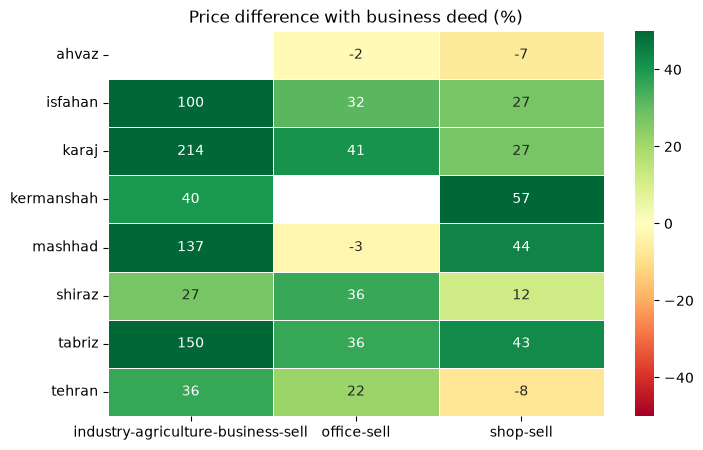

In [20]:
pivot = by_city.pivot(index="city", columns="category", values="median_diff_%")
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
            vmin=-50, vmax=50, linewidths=0.5)
plt.title("Price difference with business deed (%)")
plt.xlabel("")
plt.ylabel("")
plt.show()

<div dir="rtl">

## نتیجه فرضیه اول

در کل ایران سند تجاری در هر سه دسته با قیمت بالاتر همراه است. مغازه حدود ۱۲ درصد و دفتر حدود ۴ درصد و ملک صنعتی حدود ۷۵ درصد گران‌تر است.

ولی در تهران برای مغازه نتیجه برعکس شد. وقتی ۸ شهر را جدا بررسی کردیم دیدیم ملک صنعتی در همه شهرها با سند گران‌تر است. دفتر در بیشتر شهرها ۲۰ تا ۴۰ درصد گران‌تر است. مغازه هم در بیشتر شهرها گران‌تر است به جز تهران و اهواز. شاید دلیلش سرقفلی باشد. خیلی از مغازه‌های تهران سرقفلی‌اند و سند تجاری ندارند ولی به خاطر موقعیت‌شان گران‌اند.

پس فرضیه تأیید می‌شود ولی اندازه اثر به نوع ملک و شهر بستگی دارد.

یک محدودیت هم هست. متراژ را کنترل نکردیم و اگر ملک‌های سنددار بزرگ‌تر باشند بخشی از اختلاف به خاطر اندازه است.

</div>

<div dir="rtl">

# فرضیه دوم: امکانات لوکس و معمولی

فرض صفر این است که داشتن یک امکان روی قیمت اثری ندارد. فرض مقابل اینه که اثر داره 

طبق صورت پروژه استخر و سونا و جکوزی و باربیکیو لوکس‌اند. پارکینگ و انباری و بالکن و نگهبان را معمولی گرفتیم.

## ۸. نگاه اول به امکانات ویلاها

امکانات لوکس فقط برای خانه و ویلا پرسیده شده. پس مقایسه منصفانه فقط در همین دسته ممکن است. درصدها فقط بین کسانی حساب شده که جواب داده‌اند چون خالی بودن یعنی پرسیده نشده نه این‌که نداره اون ویلا


</div>

In [21]:
villa = sale[sale["cat3_slug"] == "house-villa-sell"]
luxury = ["has_pool", "has_sauna", "has_jacuzzi", "has_barbecue"]
regular = ["has_parking", "has_warehouse", "has_balcony", "has_security_guard"]

overview = pd.DataFrame({
    "answered": villa[luxury + regular].notna().sum(),
    "has_it": villa[luxury + regular].sum(),
})
overview["has_it_%"] = (overview["has_it"] / overview["answered"] * 100).round(1)
overview["type"] = ["luxury"] * 4 + ["regular"] * 4
overview

,answered,has_it,has_it_%,type
has_pool,18757,2447,13.0,luxury
has_sauna,18029,957,5.3,luxury
has_jacuzzi,18215,1455,8.0,luxury
has_barbecue,20339,5359,26.3,luxury
has_parking,110435,89605,81.1,regular
has_warehouse,110435,93531,84.7,regular
has_balcony,110434,79459,72.0,regular
has_security_guard,20727,5501,26.5,regular


<div dir="rtl">

## ۹. آزمون در کل ویلاها

نتیجه عجیبه
. امکانات معمولی مثل پارکینگ اثر بزرگ‌تری از امکانات لوکس نشان دادند و ویلاهای نگهبان‌دار حتی ارزان‌تر بودند.

ولی دو گروه از یک جمعیت نبودند. پارکینگ را همه ۱۱۰ هزار ویلا جواب داده بودند و امکانات لوکس را فقط حدود ۲۰ هزار ویلا.

</div>

In [22]:
def amenity_test(data, cols):
    rows = []
    for col in cols:
        answered = data[data[col].notna()]
        has_it = answered[answered[col] == True]["price_value"]
        no_it = answered[answered[col] == False]["price_value"]

        if len(has_it) < 30 or len(no_it) < 30:
            continue
        p = stats.mannwhitneyu(has_it, no_it).pvalue
        diff = (has_it.median() / no_it.median() - 1) * 100

        rows.append({
            "amenity": col,
            "has_it": len(has_it),
            "no_it": len(no_it),
            "median_diff_%": round(diff, 1),
            "mann_whitney_p": p,
            "significant": p < 0.05,
        })
    return pd.DataFrame(rows)

villa_results = amenity_test(villa, luxury + regular)
villa_results["type"] = villa_results["amenity"].map(lambda c: "luxury" if c in luxury else "regular")
villa_results.sort_values("median_diff_%", ascending=False)

,amenity,has_it,no_it,median_diff_%,mann_whitney_p,significant,type
4,has_parking,89605,20830,82.9,0.000000e+00,True,regular
6,has_balcony,79459,30975,57.1,0.000000e+00,True,regular
5,has_warehouse,93531,16904,50.0,0.000000e+00,True,regular
2,has_jacuzzi,1455,16760,37.9,2.011753e-45,True,luxury
0,has_pool,2447,16310,22.8,2.268085e-42,True,luxury
1,has_sauna,957,17072,6.8,3.302039e-11,True,luxury
3,has_barbecue,5359,14980,5.3,1.434845e-03,True,luxury
7,has_security_guard,5501,15226,-21.7,2.450197e-76,True,regular


<div dir="rtl">

## ۱۰. مقایسه روی یک جمعیت

فقط ویلاهایی را نگه داشتم که به هر چهار سؤال لوکس جواب داده بودند. حدود ۱۸ هزار ویلا ماند. حالا اثر امکانات لوکس دو تا چهار برابر شد و اثر امکانات معمولی تقریباً نصف.

تقریباً همه این ویلاها در شمال هستند. پس نتیجه درباره بازار ویلای شمال است.

</div>

In [23]:
same_group = villa[villa[luxury].notna().all(axis=1)]
print(f"ویلاهایی که به همه سوال ها در مورد لوکس بودن جواب دادن : {len(same_group):,}")

same_results = amenity_test(same_group, luxury + regular)
same_results["type"] = same_results["amenity"].map(lambda c: "luxury" if c in luxury else "regular")
display(same_results.sort_values("median_diff_%", ascending=False))

display(same_group["city_slug"].value_counts().head(10).to_frame("villas"))

ویلاهایی که به همه سوال ها در مورد لوکس بودن جواب دادن : 17,923


,amenity,has_it,no_it,median_diff_%,mann_whitney_p,significant,type
4,has_parking,16397,1526,50.0,3.396903e-76,True,regular
0,has_pool,1613,16310,40.4,3.587258e-57,True,luxury
2,has_jacuzzi,1163,16760,37.9,2.265298e-46,True,luxury
6,has_balcony,14828,3095,30.4,2.473592e-79,True,regular
3,has_barbecue,2943,14980,21.1,1.416066e-27,True,luxury
5,has_warehouse,15873,2050,20.0,1.900345e-32,True,regular
1,has_sauna,851,17072,15.3,4.579332e-15,True,luxury
7,has_security_guard,2675,15226,-16.7,1.413030e-10,True,regular


,villas
city_slug,
chamestan,2319
nur,1742
mahmudabad,1109
nowshahr,906
rasht,905
amol,634
gorgan,384
sorkhrood,349
bandar-anzali,270


<div dir="rtl">

## ۱۱. اثر امکانات در هر شهر

برای این‌که اثر مکان حذف شود آزمون را در ۶ شهری که بیشترین ویلا را دارند جدا تکرار کردم

</div>

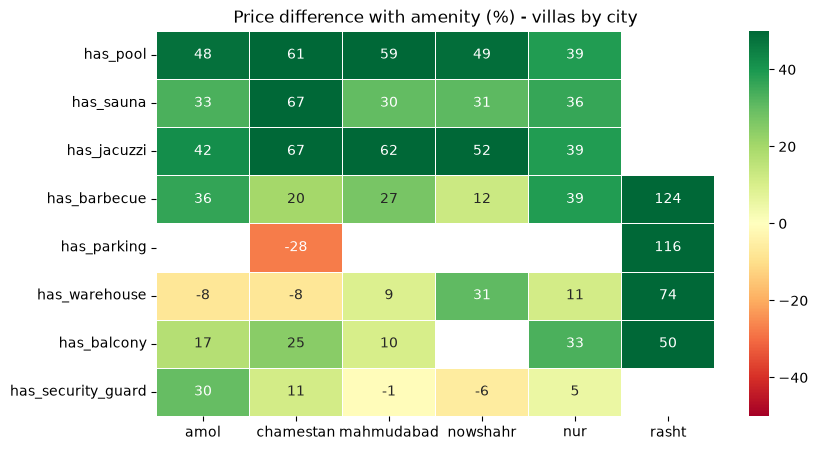

In [24]:
top_villa_cities = same_group["city_slug"].value_counts().head(6).index
city_rows = []
for city in top_villa_cities:
    result = amenity_test(same_group[same_group["city_slug"] == city], luxury + regular)
    result.insert(0, "city", city)
    city_rows.append(result)

amenity_by_city = pd.concat(city_rows, ignore_index=True)
pivot2 = (amenity_by_city
          .pivot(index="amenity", columns="city", values="median_diff_%")
          .reindex(luxury + regular))

plt.figure(figsize=(9, 5))
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="RdYlGn", center=0,
            vmin=-50, vmax=50, linewidths=0.5)
plt.title("Price difference with amenity (%) - villas by city")
plt.xlabel("")
plt.ylabel("")
plt.show()

<div dir="rtl">

## نتیجه فرضیه دوم

امکانات لوکس در همه شهرها قیمت را بالا می‌برند. ویلاهای دارای استخر یا سونا یا جکوزی حدود ۳۰ تا ۶۵ درصد گران‌ترند و باربیکیو هم اثر مثبت کمتری دارد. پس فرضیه برای امکانات لوکس تأیید می‌شود.

امکانات معمولی در کل داده اثر بزرگی داشتند. ولی داخل هر شهر اثرشان خیلی کوچک شد و گاهی مثبت و گاهی منفی بود. یعنی بیشتر آن اثر از مقایسه مناطق مختلف با هم می‌آمد نه خود امکان.

نگهبان هم در کل داده ۱۷ درصد ارزان‌تر بود ولی داخل هر شهر این اثر تقریباً از بین رفت. این نمونه خوبی از اثر متغیر مخدوش‌کننده است.

 متراژ ملک و زمین را کنترل نکردم و ویلاهای استخردار احتمالاً بزرگ‌ترند.

</div>